# News Recommendation System Project COMP9727

**Name**: PanHang\
**zID**: z5598515\
**Email**: z5598515@ad.unsw.edu.au

Three news recommendation systems were constructed and evaluated, using the dataset MIND. The adopted methods include content-based filtering (using TF-IDF/ Bert/SBert) and collaborative filtering (based on the embedding model of pytorch). The evaluation methods are Precision@K, MRR@K, NDGC@K, Recall@K, The proportion of the number of news items actually clicked by users to the total number of news items actually clicked by users.

# 1. Load Data

In [1]:
import os
import ast
from collections import defaultdict
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity, linear_kernel
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from scipy.sparse import csr_matrix

import tensorflow as tf
from tensorflow.keras import layers

pd.set_option('display.max_columns', None)

2025-08-09 15:29:45.851137: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754753386.228551      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754753386.328634      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
!pip install sentence-transformers # to load bert

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.5 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 28.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 12.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.8 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 73.9 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.9.41
    Uninstalling nvidia-nvjitlink-cu12-12.9.41:
      Successfully uninstalled nvidia-nvjitlink-cu12-12.9.41
  Attempting uninstall: nvidia-curand-cu12
    Found existing installation: nvidia-curand-cu12 10.3.10.19
    Uninstalling nvidia-curand-cu12-

In [3]:
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)

In [4]:
import random
import numpy as np
import tensorflow as tf
import os

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seed()

In [5]:
behaviors = pd.read_csv('/kaggle/input/mind-news-dataset/MINDsmall_train/behaviors.tsv', sep='\t', 
                        names=["Impression_ID", "User_ID", "Time", "History", "Impressions"])

news = pd.read_csv('/kaggle/input/mind-news-dataset/MINDsmall_train/news.tsv', sep='\t',
                   names=["News_ID", "Category", "SubCategory", "Title", "Abstract", "URL", "Title_Entities", "Abstract_Entities"])


In [6]:
behaviors.info(),behaviors.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156965 entries, 0 to 156964
Data columns (total 5 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Impression_ID  156965 non-null  int64 
 1   User_ID        156965 non-null  object
 2   Time           156965 non-null  object
 3   History        153727 non-null  object
 4   Impressions    156965 non-null  object
dtypes: int64(1), object(4)
memory usage: 6.0+ MB


(None, (156965, 5))

In [7]:
news.info(),news.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51282 entries, 0 to 51281
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   News_ID            51282 non-null  object
 1   Category           51282 non-null  object
 2   SubCategory        51282 non-null  object
 3   Title              51282 non-null  object
 4   Abstract           48616 non-null  object
 5   URL                51282 non-null  object
 6   Title_Entities     51279 non-null  object
 7   Abstract_Entities  51278 non-null  object
dtypes: object(8)
memory usage: 3.1+ MB


(None, (51282, 8))

# 2. Data Preprocessing

In [8]:
news.head()

,News_ID,Category,SubCategory,Title,Abstract,URL,Title_Entities,Abstract_Entities
0,N55528,lifestyle,lifestyleroyals,"The Brands Queen Elizabeth, Prince Charles, an...","Shop the notebooks, jackets, and more that the...",https://assets.msn.com/labs/mind/AAGH0ET.html,"[{""Label"": ""Prince Philip, Duke of Edinburgh"",...",[]
1,N19639,health,weightloss,50 Worst Habits For Belly Fat,These seemingly harmless habits are holding yo...,https://assets.msn.com/labs/mind/AAB19MK.html,"[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik...","[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik..."
2,N61837,news,newsworld,The Cost of Trump's Aid Freeze in the Trenches...,Lt. Ivan Molchanets peeked over a parapet of s...,https://assets.msn.com/labs/mind/AAJgNsz.html,[],"[{""Label"": ""Ukraine"", ""Type"": ""G"", ""WikidataId..."
3,N53526,health,voices,I Was An NBA Wife. Here's How It Affected My M...,"I felt like I was a fraud, and being an NBA wi...",https://assets.msn.com/labs/mind/AACk2N6.html,[],"[{""Label"": ""National Basketball Association"", ..."
4,N38324,health,medical,"How to Get Rid of Skin Tags, According to a De...","They seem harmless, but there's a very good re...",https://assets.msn.com/labs/mind/AAAKEkt.html,"[{""Label"": ""Skin tag"", ""Type"": ""C"", ""WikidataI...","[{""Label"": ""Skin tag"", ""Type"": ""C"", ""WikidataI..."


In [9]:
behaviors.head()

,Impression_ID,User_ID,Time,History,Impressions
0,1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N104...,N55689-1 N35729-0
1,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...
2,3,U73700,11/14/2019 7:01:48 AM,N10732 N25792 N7563 N21087 N41087 N5445 N60384...,N50014-0 N23877-0 N35389-0 N49712-0 N16844-0 N...
3,4,U34670,11/11/2019 5:28:05 AM,N45729 N2203 N871 N53880 N41375 N43142 N33013 ...,N35729-0 N33632-0 N49685-1 N27581-0
4,5,U8125,11/12/2019 4:11:21 PM,N10078 N56514 N14904 N33740,N39985-0 N36050-0 N16096-0 N8400-1 N22407-0 N6...


### 2.1. Data Cleaning

In [10]:
def parse_impressions(imp_str):
    if pd.isna(imp_str):
        return []
    items = imp_str.strip().split(' ')
    return [(i.split('-')[0], int(i.split('-')[1])) for i in items]

behaviors['Impressions_parsed'] = behaviors['Impressions'].apply(parse_impressions)


In [11]:
def parse_history(history_str):
    if pd.isna(history_str):
        return []
    return history_str.strip().split(' ')

behaviors['History_parsed'] = behaviors['History'].apply(parse_history)


In [12]:
behaviors

,Impression_ID,User_ID,Time,History,Impressions,Impressions_parsed,History_parsed
0,1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N104...,N55689-1 N35729-0,"[(N55689, 1), (N35729, 0)]","[N55189, N42782, N34694, N45794, N18445, N6330..."
1,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...,"[(N20678, 0), (N39317, 0), (N58114, 0), (N2049...","[N31739, N6072, N63045, N23979, N35656, N43353..."
2,3,U73700,11/14/2019 7:01:48 AM,N10732 N25792 N7563 N21087 N41087 N5445 N60384...,N50014-0 N23877-0 N35389-0 N49712-0 N16844-0 N...,"[(N50014, 0), (N23877, 0), (N35389, 0), (N4971...","[N10732, N25792, N7563, N21087, N41087, N5445,..."
3,4,U34670,11/11/2019 5:28:05 AM,N45729 N2203 N871 N53880 N41375 N43142 N33013 ...,N35729-0 N33632-0 N49685-1 N27581-0,"[(N35729, 0), (N33632, 0), (N49685, 1), (N2758...","[N45729, N2203, N871, N53880, N41375, N43142, ..."
4,5,U8125,11/12/2019 4:11:21 PM,N10078 N56514 N14904 N33740,N39985-0 N36050-0 N16096-0 N8400-1 N22407-0 N6...,"[(N39985, 0), (N36050, 0), (N16096, 0), (N8400...","[N10078, N56514, N14904, N33740]"
...,...,...,...,...,...,...,...
156960,156961,U21593,11/14/2019 10:24:05 PM,N7432 N58559 N1954 N43353 N14343 N13008 N28833...,N2235-0 N22975-0 N64037-0 N47652-0 N11378-0 N4...,"[(N2235, 0), (N22975, 0), (N64037, 0), (N47652...","[N7432, N58559, N1954, N43353, N14343, N13008,..."
156961,156962,U10123,11/13/2019 6:57:04 AM,N9803 N104 N24462 N57318 N55743 N40526 N31726 ...,N3841-0 N61571-0 N58813-0 N28213-0 N4428-0 N25...,"[(N3841, 0), (N61571, 0), (N58813, 0), (N28213...","[N9803, N104, N24462, N57318, N55743, N40526, ..."
156962,156963,U75630,11/14/2019 10:58:13 AM,N29898 N59704 N4408 N9803 N53644 N26103 N812 N...,N55913-0 N62318-0 N53515-0 N10960-0 N9135-0 N5...,"[(N55913, 0), (N62318, 0), (N53515, 0), (N1096...","[N29898, N59704, N4408, N9803, N53644, N26103,..."
156963,156964,U44625,11/13/2019 2:57:02 PM,N4118 N47297 N3164 N43295 N6056 N38747 N42973 ...,N6219-0 N3663-0 N31147-0 N58363-0 N4107-0 N457...,"[(N6219, 0), (N3663, 0), (N31147, 0), (N58363,...","[N4118, N47297, N3164, N43295, N6056, N38747, ..."


In [13]:
def check_df_shape_and_null(df):
    print("The shape of df:", df.shape)
    df.info()
    
    print("\nThe number of missing values in each column:")
    print(df.isnull().sum())

In [14]:
check_df_shape_and_null(news)
check_df_shape_and_null(behaviors)

The shape of df: (51282, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51282 entries, 0 to 51281
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   News_ID            51282 non-null  object
 1   Category           51282 non-null  object
 2   SubCategory        51282 non-null  object
 3   Title              51282 non-null  object
 4   Abstract           48616 non-null  object
 5   URL                51282 non-null  object
 6   Title_Entities     51279 non-null  object
 7   Abstract_Entities  51278 non-null  object
dtypes: object(8)
memory usage: 3.1+ MB

The number of missing values in each column:
News_ID                 0
Category                0
SubCategory             0
Title                   0
Abstract             2666
URL                     0
Title_Entities          3
Abstract_Entities       4
dtype: int64
The shape of df: (156965, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156965 e

In [15]:
news_clean = news.dropna()
news_clean.drop_duplicates(subset=['News_ID'], inplace=True)

behaviors_clean = behaviors.dropna()
behaviors_clean.drop_duplicates(subset=['Impression_ID'], inplace=True)

/tmp/ipykernel_35/676842085.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  news_clean.drop_duplicates(subset=['News_ID'], inplace=True)
/tmp/ipykernel_35/676842085.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  behaviors_clean.drop_duplicates(subset=['Impression_ID'], inplace=True)


dropna() is used to delete rows containing null values. This is particularly important in columns like Title, Abstract or Impressions, as this information is crucial in the process of content representation and label construction.

drop_duplicates() is used to remove duplicate entries based on News_ID in news.tsv and Impression_ID in drivs.tsv to avoid bias caused by duplicate data.

In [16]:
check_df_shape_and_null(news_clean)
check_df_shape_and_null(behaviors_clean)

The shape of df: (48612, 8)
<class 'pandas.core.frame.DataFrame'>
Index: 48612 entries, 0 to 51280
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   News_ID            48612 non-null  object
 1   Category           48612 non-null  object
 2   SubCategory        48612 non-null  object
 3   Title              48612 non-null  object
 4   Abstract           48612 non-null  object
 5   URL                48612 non-null  object
 6   Title_Entities     48612 non-null  object
 7   Abstract_Entities  48612 non-null  object
dtypes: object(8)
memory usage: 3.3+ MB

The number of missing values in each column:
News_ID              0
Category             0
SubCategory          0
Title                0
Abstract             0
URL                  0
Title_Entities       0
Abstract_Entities    0
dtype: int64
The shape of df: (153727, 7)
<class 'pandas.core.frame.DataFrame'>
Index: 153727 entries, 0 to 156964
Data columns (

In [39]:
import pandas as pd


# Convert the 'Time' column to datetime type 
interactions_df['Time'] = pd.to_datetime(interactions_df['Time'], format='%Y-%m-%d')  

# Step 1: Sort by Time to ensure chronological order
interactions_df = interactions_df.sort_values('Time').reset_index(drop=True)

#  Extract and sort unique dates
unique_dates = sorted(interactions_df['Time'].dt.date.unique())

# Print unique dates for confirmation
print("Unique dates:", unique_dates)

# Step 3: Use the first 5 days as training dates and the last day as test date
if len(unique_dates) >= 6:
    train_dates = unique_dates[:5]  # First 5 days
    test_dates = [unique_dates[-1]]  # Last day
else:
    raise ValueError("Fewer than 6 unique dates. Cannot split into first 5 days for training + last day for testing.")

# Step 4: Filter training and testing sets based on dates
train_df = interactions_df[interactions_df['Time'].dt.date.isin(train_dates)]
test_df = interactions_df[interactions_df['Time'].dt.date.isin(test_dates)]

# Step 5: Extract X and y
X_train = train_df[['user_encoded', 'news_encoded']]
y_train = train_df['Label']

X_test = test_df[['user_encoded', 'news_encoded']]
y_test = test_df['Label']

# Calculate training and test set proportions (added for verification)
total_samples = len(interactions_df)
train_ratio = len(train_df) / total_samples * 100
test_ratio = len(test_df) / total_samples * 100

# Check dataset sizes 
# print("Training set size:", X_train.shape)
# print("Test set size:", X_test.shape)
# print(f"Training set ratio: {train_ratio:.2f}%")
# print(f"Test set ratio: {test_ratio:.2f}%")


Unique dates: [datetime.date(2019, 11, 9), datetime.date(2019, 11, 10), datetime.date(2019, 11, 11), datetime.date(2019, 11, 12), datetime.date(2019, 11, 13), datetime.date(2019, 11, 14)]


# 4. Experiment

### 4.1. Content Based Filtering - TF-IDF

The Content-Based Filtering approach recommends news based on content similarity between articles, without taking into account the behavior of other users.
News content is represented by transforming the combined text of Title + Abstract into a fixed-dimensional TF-IDF vector.
Then, a k-Nearest Neighbors (k-NN) algorithm based on cosine similarity is used to find the most similar news articles.

In [41]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import roc_auc_score

news_clean['full_text_clean'] = news_clean['Title'] + ' ' + news_clean['Abstract']

# Convert Time to datetime
behaviors_clean['Time'] = pd.to_datetime(behaviors_clean['Time'])

# Sort by Time
behaviors_clean = behaviors_clean.sort_values('Time').reset_index(drop=True)

# Extract and sort unique dates
unique_dates = sorted(behaviors_clean['Time'].dt.date.unique())

# Ensure at least 6 days for split
if len(unique_dates) < 6:
    raise ValueError("Not enough unique dates to split: need at least 6.")

# Define training and test dates
train_dates = unique_dates[:5]  # first 5 days
test_dates = [unique_dates[-1]]  # last day

# Filter training and test sets
train_df = behaviors_clean[behaviors_clean['Time'].dt.date.isin(train_dates)].copy()
test_df = behaviors_clean[behaviors_clean['Time'].dt.date.isin(test_dates)].copy()

# Note: If total span < 8 weeks, there may be overlap; if >8 weeks, middle unused

# Hyperparameter range
feature_range = [7000]
K = 10
results = []

# newsid2idx for quick lookup
newsid2idx = {nid: i for i, nid in enumerate(news_clean['News_ID'])}

# User profile function
def get_user_profile(history_list, tfidf_matrix):
    indices = [newsid2idx[nid] for nid in history_list if nid in newsid2idx]
    if not indices:
        return np.zeros((tfidf_matrix.shape[1],))
    return tfidf_matrix[indices].mean(axis=0).A1

# Recommend function (now also returns similarities for AUC)
def recommend_for_row(row, K, tfidf_matrix):
    history = row['History'].split() if pd.notna(row['History']) else []
    user_vec = get_user_profile(history, tfidf_matrix).reshape(1, -1)
    impression_items = row['Impressions'].split()
    candidates = [item.split('-')[0] for item in impression_items]
    labels = [1 if item.endswith('-1') else 0 for item in impression_items]  # 0 or 1 labels
    candidate_idxs = [newsid2idx[nid] for nid in candidates if nid in newsid2idx]
    if not candidate_idxs:
        return [], [], []
    candidate_vecs = tfidf_matrix[candidate_idxs]
    sims = cosine_similarity(user_vec, candidate_vecs).flatten()
    topk_idx = np.argsort(sims)[-K:][::-1]
    recs = [candidates[i] for i in topk_idx]
    # Filter labels and sims to match candidates (assuming all candidates are in newsid2idx)
    filtered_labels = [labels[i] for i in range(len(candidates)) if candidates[i] in newsid2idx]
    filtered_sims = sims
    return recs, filtered_sims, filtered_labels

# Evaluation functions
def calc_precision(row, K):
    actual = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['cb_recommend'][:K] if isinstance(row['cb_recommend'], list) else []
    return sum(1 for nid in recs if nid in actual) / K if recs else 0

def calc_recall(row, K):
    actual = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['cb_recommend'][:K] if isinstance(row['cb_recommend'], list) else []
    if not actual:
        return 0
    return sum(1 for nid in recs if nid in actual) / len(actual)

def calc_mrr(row, K):
    actual = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['cb_recommend'][:K] if isinstance(row['cb_recommend'], list) else []
    for idx, nid in enumerate(recs, 1):
        if nid in actual:
            return 1 / idx
    return 0

def calc_ndcg(row, K):
    actual = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['cb_recommend'][:K] if isinstance(row['cb_recommend'], list) else []
    dcg = sum(1 / np.log2(i + 2) for i, nid in enumerate(recs) if nid in actual)
    idcg = sum(1 / np.log2(i + 2) for i in range(min(len(actual), K)))
    return dcg / idcg if idcg > 0 else 0

def calc_hit_rate(row, K):
    actual = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['cb_recommend'][:K] if isinstance(row['cb_recommend'], list) else []
    return 1 if any(nid in actual for nid in recs) else 0

def calc_auc(row):
    sims = row['sims']
    labels = row['labels']
    if len(set(labels)) < 2:  # Need both classes for AUC
        return 0.5  # Or np.nan, but for averaging, use 0.5
    try:
        return roc_auc_score(labels, sims)
    except:
        return 0.5

# Function to evaluate a dataframe for a given tfidf_matrix
def evaluate_df(df, tfidf_matrix, K):
    # Generate recommendations, sims, labels
    df[['cb_recommend', 'sims', 'labels']] = df.apply(
        lambda row: pd.Series(recommend_for_row(row, K, tfidf_matrix)), axis=1
    )
    
    # Calculate metrics
    df['precision'] = df.apply(lambda row: calc_precision(row, K), axis=1)
    df['recall'] = df.apply(lambda row: calc_recall(row, K), axis=1)
    df['mrr'] = df.apply(lambda row: calc_mrr(row, K), axis=1)
    df['ndcg'] = df.apply(lambda row: calc_ndcg(row, K), axis=1)
    df['hit_rate'] = df.apply(lambda row: calc_hit_rate(row, K), axis=1)
    df['auc'] = df.apply(calc_auc, axis=1)
    
    # Compute means
    results = {
        'precision@10': df['precision'].mean(),
        'recall@10': df['recall'].mean(),
        'mrr@10': df['mrr'].mean(),
        'ndcg@10': df['ndcg'].mean(),
        'hit_rate@10': df['hit_rate'].mean(),
        'auc': df['auc'].mean()
    }
    return results

# Tune on train
for max_f in feature_range:
    print(f"\n Testing max_features = {max_f}")
    
    vectorizer = TfidfVectorizer(max_features=max_f)
    tfidf_matrix = vectorizer.fit_transform(news_clean['full_text_clean'])
    
    train_results = evaluate_df(train_df, tfidf_matrix, K)
    
    results.append({
        'max_features': max_f,
        **train_results
    })

results_df = pd.DataFrame(results)
best_row = results_df.sort_values(by='ndcg@10', ascending=False).iloc[0]

print("\nAll results on train:")
print(results_df)

print(f"\nBest max_features found on train: {best_row['max_features']} with:")
for metric in ['precision@10', 'recall@10', 'mrr@10', 'ndcg@10', 'hit_rate@10', 'auc']:
    print(f" - {metric.capitalize()}: {best_row[metric]:.4f}")

# Evaluate on test with best
best_max_f = int(best_row['max_features'])
print(f"\nEvaluating best max_features ({best_max_f}) on test set")

vectorizer = TfidfVectorizer(max_features=best_max_f)
tfidf_matrix = vectorizer.fit_transform(news_clean['full_text_clean'])

test_results = evaluate_df(test_df, tfidf_matrix, K)

print(f"\nTest set results:")
for metric, value in test_results.items():
    print(f" - {metric.capitalize()}: {value:.4f}")

/tmp/ipykernel_35/1058014299.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  news_clean['full_text_clean'] = news_clean['Title'] + ' ' + news_clean['Abstract']
/tmp/ipykernel_35/1058014299.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  behaviors_clean['Time'] = pd.to_datetime(behaviors_clean['Time'])



 Testing max_features = 7000

All results on train:
   max_features  precision@10  recall@10    mrr@10   ndcg@10  hit_rate@10  \
0          7000      0.065738   0.525241  0.259562  0.311162     0.590885   

        auc  
0  0.554502  

Best max_features found on train: 7000.0 with:
 - Precision@10: 0.0657
 - Recall@10: 0.5252
 - Mrr@10: 0.2596
 - Ndcg@10: 0.3112
 - Hit_rate@10: 0.5909
 - Auc: 0.5545

Evaluating best max_features (7000) on test set

Test set results:
 - Precision@10: 0.0657
 - Recall@10: 0.5252
 - Mrr@10: 0.2596
 - Ndcg@10: 0.3112
 - Hit_rate@10: 0.5909
 - Auc: 0.5545


### select Best K value

/tmp/ipykernel_35/3244241836.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  news_clean['full_text_clean'] = news_clean['Title'].fillna('') + ' ' + news_clean['Abstract'].fillna('')



Evaluating on TEST set with K = 10

Evaluating on TEST set with K = 20

Evaluating on TEST set with K = 30

Metrics on TEST set by K:
   precision    recall       mrr      ndcg  hit_rate       auc   K
0   0.119044  0.560001  0.291004  0.340241  0.633103  0.554502  10
1   0.113926  0.720839  0.302042  0.385507  0.790421  0.554502  20
2   0.112191  0.805867  0.305017  0.406311  0.863739  0.554502  30


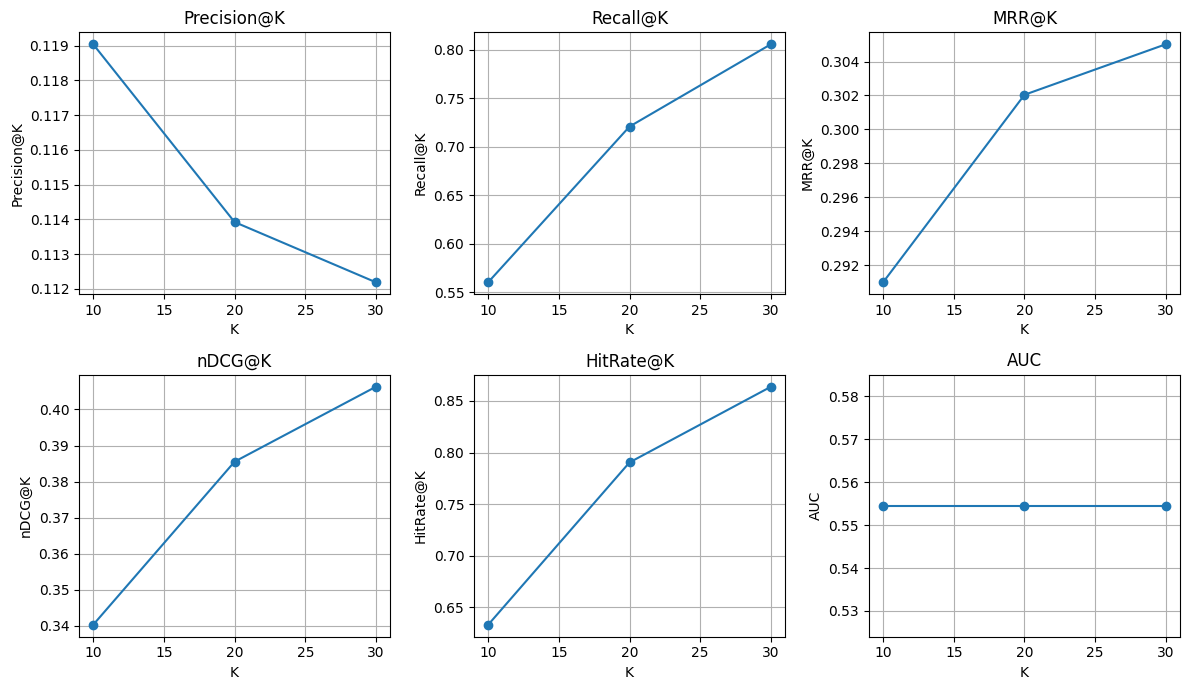

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import roc_auc_score

news_clean['full_text_clean'] = news_clean['Title'] + ' ' + news_clean['Abstract']

# Convert Time to datetime
behaviors_clean['Time'] = pd.to_datetime(behaviors_clean['Time'])

# Sort by Time
behaviors_clean = behaviors_clean.sort_values('Time').reset_index(drop=True)

# Extract and sort unique dates
unique_dates = sorted(behaviors_clean['Time'].dt.date.unique())

# Ensure at least 6 days for split
if len(unique_dates) < 6:
    raise ValueError("Not enough unique dates to split: need at least 6.")

# Define training and test dates
train_dates = unique_dates[:5]  # first 5 days
test_dates = [unique_dates[-1]]  # last day

# Filter training and test sets
train_df = behaviors_clean[behaviors_clean['Time'].dt.date.isin(train_dates)].copy()
test_df = behaviors_clean[behaviors_clean['Time'].dt.date.isin(test_dates)].copy()

# set different k value
K_values = [10, 20, 30]
max_features = 7000  


newsid2idx = {nid: i for i, nid in enumerate(news_clean['News_ID'])}

vectorizer = TfidfVectorizer(max_features=max_features)
tfidf_matrix = vectorizer.fit_transform(news_clean['full_text_clean'])


def get_user_profile(history_list, tfidf_matrix):
    indices = [newsid2idx[nid] for nid in history_list if nid in newsid2idx]
    if not indices:
        return np.zeros((tfidf_matrix.shape[1],))
    return tfidf_matrix[indices].mean(axis=0).A1

def recommend_for_row(row, K, tfidf_matrix):
    history = row['History'].split() if pd.notna(row['History']) else []
    user_vec = get_user_profile(history, tfidf_matrix).reshape(1, -1)

    impression_items = row['Impressions'].split() if pd.notna(row['Impressions']) else []
    raw_candidates = [item.split('-')[0] for item in impression_items]
    raw_labels = [1 if item.endswith('-1') else 0 for item in impression_items]

    filtered_candidates = []
    filtered_labels = []
    candidate_idxs = []
    for c, lbl in zip(raw_candidates, raw_labels):
        if c in newsid2idx:
            filtered_candidates.append(c)
            filtered_labels.append(lbl)
            candidate_idxs.append(newsid2idx[c])

    if not candidate_idxs:
        return [], np.array([]), []

    candidate_vecs = tfidf_matrix[candidate_idxs]
    sims = cosine_similarity(user_vec, candidate_vecs).flatten()

    topk_count = min(K, len(filtered_candidates))
    topk_idx = np.argsort(sims)[-topk_count:][::-1]
    recs = [filtered_candidates[i] for i in topk_idx]

    return recs, sims, filtered_labels

def calc_precision(row, K):
    actual = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')]) if pd.notna(row['Impressions']) else set()
    recs = row['cb_recommend'][:K] if isinstance(row['cb_recommend'], list) else []
    if not recs:
        return 0.0
    return sum(1 for nid in recs if nid in actual) / len(recs)

def calc_recall(row, K):
    actual = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')]) if pd.notna(row['Impressions']) else set()
    if not actual:
        return 0.0
    recs = row['cb_recommend'][:K] if isinstance(row['cb_recommend'], list) else []
    return sum(1 for nid in recs if nid in actual) / len(actual)

def calc_mrr(row, K):
    actual = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')]) if pd.notna(row['Impressions']) else set()
    recs = row['cb_recommend'][:K] if isinstance(row['cb_recommend'], list) else []
    for idx, nid in enumerate(recs, 1):
        if nid in actual:
            return 1.0 / idx
    return 0.0

def calc_ndcg(row, K):
    actual = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')]) if pd.notna(row['Impressions']) else set()
    recs = row['cb_recommend'][:K] if isinstance(row['cb_recommend'], list) else []
    if not recs:
        return 0.0
    dcg = 0.0
    for i, nid in enumerate(recs):
        if nid in actual:
            dcg += 1.0 / np.log2(i + 2)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(actual), len(recs))))
    return (dcg / idcg) if idcg > 0 else 0.0

def calc_hit_rate(row, K):
    actual = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')]) if pd.notna(row['Impressions']) else set()
    recs = row['cb_recommend'][:K] if isinstance(row['cb_recommend'], list) else []
    return 1.0 if any(nid in actual for nid in recs) else 0.0

def calc_auc(row):
    sims = row['sims']
    labels = row['labels']
    if sims is None or len(sims) == 0 or labels is None or len(labels) == 0:
        return 0.5
    if len(set(labels)) < 2:
        return 0.5
    try:
        return roc_auc_score(labels, sims)
    except Exception:
        return 0.5

def evaluate_df(df, tfidf_matrix, K):
    out = df.copy()
    out[['cb_recommend', 'sims', 'labels']] = out.apply(
        lambda row: pd.Series(recommend_for_row(row, K, tfidf_matrix)), axis=1
    )

    out['precision'] = out.apply(lambda row: calc_precision(row, K), axis=1)
    out['recall']    = out.apply(lambda row: calc_recall(row, K), axis=1)
    out['mrr']       = out.apply(lambda row: calc_mrr(row, K), axis=1)
    out['ndcg']      = out.apply(lambda row: calc_ndcg(row, K), axis=1)
    out['hit_rate']  = out.apply(lambda row: calc_hit_rate(row, K), axis=1)
    out['auc']       = out.apply(calc_auc, axis=1)

    results = {
        'precision': out['precision'].mean(),
        'recall': out['recall'].mean(),
        'mrr': out['mrr'].mean(),
        'ndcg': out['ndcg'].mean(),
        'hit_rate': out['hit_rate'].mean(),
        'auc': out['auc'].mean(),
    }
    return results


metrics_records = []
for K in K_values:
    print(f"\nEvaluating on TEST set with K = {K}")
    res_test = evaluate_df(test_df, tfidf_matrix, K)
    res_test['K'] = K
    metrics_records.append(res_test)

metrics_k_df = pd.DataFrame(metrics_records).sort_values('K')
print("\nMetrics on TEST set by K:")
print(metrics_k_df)


fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.ravel()

plot_order = [
    ('precision', 'Precision@K'),
    ('recall',    'Recall@K'),
    ('mrr',       'MRR@K'),
    ('ndcg',      'nDCG@K'),
    ('hit_rate',  'HitRate@K'),
    ('auc',       'AUC'),
]

for ax, (col, title) in zip(axes, plot_order):
    ax.plot(metrics_k_df['K'], metrics_k_df[col], marker='o')
    ax.set_xlabel('K')
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.grid(True)

plt.tight_layout()
plt.show()


Precision@10 reaches its peak (0.119) when K=10, indicating that the proportion of relevant news articles is highest within the top 10 recommendations presented to users.

Although Recall, Hit Rate, and nDCG tend to increase with higher K values, this is primarily due to the expansion of the recommendation list, which inevitably includes more irrelevant news articles.

In practical scenarios, users typically only engage with the initial few recommendations rather than browsing through 20 or 30 items. Therefore, maintaining high Precision is more crucial than pursuing higher Recall.